# Stage 10 — Simple neural network

A small MLP (one hidden layer, 128 units, ReLU) fitted with a hand-rolled
PyTorch training loop, wrapped in the Stage 4 `Model` protocol and
registered through the Stage 9 registry.

The pedagogical payoff is the **live train-vs-validation loss curve**
(Cell 5): the facilitator points at the epoch where validation loss
bottoms out and starts rising, and the audience sees overfitting happen
in real time.  Intent §Purpose is clear that Stage 10's *analytical*
contribution is modest — the linear baseline (Stage 4) + SARIMAX
(Stage 7) already beat a single MLP on the weather-only feature set;
the stage's load-bearing contribution is the **scaffold** (training-loop
conventions, reproducibility discipline, registry round-trip) that
Stage 11's temporal architecture inherits.

- **Intent:** `docs/intent/10-simple-nn.md`.
- **Plan:** `docs/plans/active/10-simple-nn.md` (moved to `completed/`
  at T7).
- **Previous stage:** Stage 9 model registry — the four-verb `save` /
  `load` / `list_runs` / `describe` surface that this notebook queries
  at Cell 8 for the cross-model comparison.

Plan decisions applied here: D3 (default architecture —
`hidden_sizes=[128]`, `activation=relu`, `lr=1e-3`, `max_epochs=100`,
`patience=10`), D4 (z-score normalisation stored in `register_buffer`
so it round-trips through `state_dict`), D6 (the `loss_history_`
attribute + `plots.loss_curve` helper + the `epoch_callback` seam for
the live-plot moment), D7' (four-stream seeding for CPU bit-identity),
D8 (cold-start per fold), D9 (internal 10 % val tail + best-epoch
restore), D11 (auto-device selector — this notebook pins `device="cpu"`
so the run is deterministic and laptop-friendly).


In [1]:
# T6 Cell 1 — Bootstrap: walk up to the repo root so
# ``from bristol_ml import ...`` and Hydra's ``conf/`` both resolve,
# then import the Stage 4 / Stage 6 / Stage 9 surfaces we need.

import os
import sys
import time
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.parent != REPO_ROOT and not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402
import torch  # noqa: E402
from IPython.display import clear_output, display  # noqa: E402

from bristol_ml import load_config  # noqa: E402
from bristol_ml.evaluation import plots  # noqa: E402
from bristol_ml.evaluation.harness import evaluate  # noqa: E402
from bristol_ml.evaluation.metrics import METRIC_REGISTRY  # noqa: E402
from bristol_ml.features import assembler  # noqa: E402
from bristol_ml.models.linear import LinearModel  # noqa: E402
from bristol_ml.models.naive import NaiveModel  # noqa: E402
from bristol_ml.models.nn.mlp import NnMlpModel  # noqa: E402
from conf._schemas import LinearConfig, NaiveConfig, NnMlpConfig  # noqa: E402

# Apply the Okabe-Ito palette + figsize defaults (Stage 6 D2 / D5).
plots.apply_plots_config(
    load_config(
        config_path=REPO_ROOT / "conf",
        overrides=["model=nn_mlp"],
    ).evaluation.plots
)

# Notebook-scope torch device: pinned to CPU so the live demo is
# deterministic and laptop-friendly (plan AC-5).  The CUDA / MPS paths
# are exercised by the ``@pytest.mark.gpu`` tests and by the
# ``_select_device`` helper used from a fresh Python session — see
# ``docs/architecture/layers/models-nn.md``.
print(f"torch version: {torch.__version__}")
print(f"torch cuda available: {torch.cuda.is_available()}")
print("Notebook pins device='cpu' so two runs of this notebook yield identical weights.")

torch version: 2.11.0+cu128
torch cuda available: True
Notebook pins device='cpu' so two runs of this notebook yield identical weights.


## Data — 60 days of hourly GB demand + weather

We load the Stage 3 `weather_only` feature cache and keep the last
60 days (1440 rows).  That window is small enough that a 1-hidden-layer
MLP fits in a handful of seconds on CI CPU — the point of the cell is
to surface the **shape** of the training signal (hourly, weather-only,
target `nd_mw`), not to push for a leaderboard win.

The `features.assembler.load` helper validates the parquet schema on
read (it rejects missing or extra columns), so if the cache is missing
or stale the cell fails loudly with a schema-mismatch error.  Rebuild
with `python -m bristol_ml.features.assembler` if that happens.


In [2]:
# T6 Cell 3 — Load the Stage 3 weather_only feature cache and keep
# the last 60 days.  A short window keeps the live-demo fit snappy
# (~5-10 s on a 4-core laptop) and makes the "validation loss bottoms
# out" moment land early enough that the audience is still watching.

cfg = load_config(
    config_path=REPO_ROOT / "conf",
    overrides=["model=nn_mlp"],
)
assert cfg.features.weather_only is not None

features_path = cfg.features.weather_only.cache_dir / cfg.features.weather_only.cache_filename
df = assembler.load(features_path).set_index("timestamp_utc")

# Last ~60 days (1440 rows) — see the cell docstring in Cell 2.
df = df.iloc[-24 * 60 :].copy()
target = df["nd_mw"].astype("float64")
feature_cols = [c for c, _ in assembler.WEATHER_VARIABLE_COLUMNS]
features = df[feature_cols].astype("float64")
print(f"Feature table: {features.shape} ({features.index.min()} -> {features.index.max()})")
print(f"Target mean: {target.mean():,.0f} MW; std: {target.std():,.0f} MW")
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

Feature table: (1440, 5) (2023-11-02 00:00:00+00:00 -> 2023-12-31 23:00:00+00:00)
Target mean: 29,637 MW; std: 6,505 MW
Feature columns (5): ['temperature_2m', 'dew_point_2m', 'wind_speed_10m', 'cloud_cover', 'shortwave_radiation']


## The demo moment — live train-vs-validation loss curve

`NnMlpModel.fit(..., epoch_callback=on_epoch)` invokes `on_epoch` after
every epoch with the per-epoch `{"epoch", "train_loss", "val_loss"}`
dict (plan D6).  The notebook owns the live-plot logic — the models
layer never imports `IPython` — so the seam is a one-function callback
that appends to a list and redraws the figure.

What to watch for:

- **Train loss** falls monotonically (orange) — the optimiser is doing
  its job on the training slice.
- **Validation loss** (sky blue) falls, bottoms out, and starts rising.
  The epoch of the minimum is the point where the model stops learning
  generalisable structure and starts memorising training noise.
- **Early stopping** (plan D9) waits `patience=10` epochs past the
  best-seen validation loss, then stops and restores the best-epoch
  weights.  The saved artefact is therefore the *best* epoch's weights,
  not the last epoch's.

With the defaults below (`max_epochs=40`, `patience=5`) the U-shape is
typically visible by epoch 10-15 on the 60-day window.  A laptop-only
audience can crank `hidden_sizes=[256, 128]` to see the U-shape shift
right (more capacity → later overfit).


In [3]:
# T6 Cell 5 — Live train-vs-validation loss curve.  AC-3 evidence.
#
# Notebook-tuned architecture: 40 epochs / patience=5 / device=cpu so
# the run is deterministic and finishes in ~5-10 s on a 4-core laptop.
# The live plot redraws every epoch via ``clear_output(wait=True)`` +
# ``display_id`` — no coupling between the models layer and matplotlib.

nn_cfg = NnMlpConfig(
    target_column="nd_mw",
    hidden_sizes=[128],
    activation="relu",
    dropout=0.0,
    learning_rate=1e-3,
    weight_decay=0.0,
    batch_size=32,
    max_epochs=40,
    patience=5,
    device="cpu",
)
model = NnMlpModel(nn_cfg)

handle = display(plt.figure(), display_id=True)
history: list[dict[str, float]] = []


def on_epoch(entry: dict[str, float]) -> None:
    history.append(entry)
    fig = plots.loss_curve(
        history,
        title=f"Training progress — epoch {int(entry['epoch'])}",
    )
    clear_output(wait=True)
    handle.update(fig)
    plt.close(fig)


t0 = time.time()
model.fit(features, target, seed=0, epoch_callback=on_epoch)
elapsed = time.time() - t0
clear_output(wait=True)
print(f"NnMlpModel.fit: {elapsed:.2f}s over {len(model.loss_history_)} epoch(s).")
print(f"Best epoch: {model.metadata.hyperparameters['best_epoch']} (early-stop restored).")
print(f"Device resolved: {model.metadata.hyperparameters['device_resolved']}.")

NnMlpModel.fit: 4.06s over 9 epoch(s).
Best epoch: 4 (early-stop restored).
Device resolved: cpu.


<Figure size 1320x880 with 0 Axes>

## Reading the final curve

The live curve above is discarded when the cell re-renders.  The cell
below reproduces the same curve with `plots.loss_curve(history)` for
the record — exactly the same helper, just called on the settled
history.  Two things to note in the static plot:

- The **gap** between train and validation loss at the best epoch is
  the model's irreducible generalisation gap on this window.  A big
  gap on a narrow feature set (5 weather columns) is expected — there
  is not enough signal for the network to close the gap without
  overfitting.
- The **right-hand rise** in validation loss past the best epoch is
  the reason Stage 9's registry records the *best-epoch* weights, not
  the last epoch's.  `plan D9` / `NnMlpModel._restore_best_state_dict`
  is the load-bearing piece.


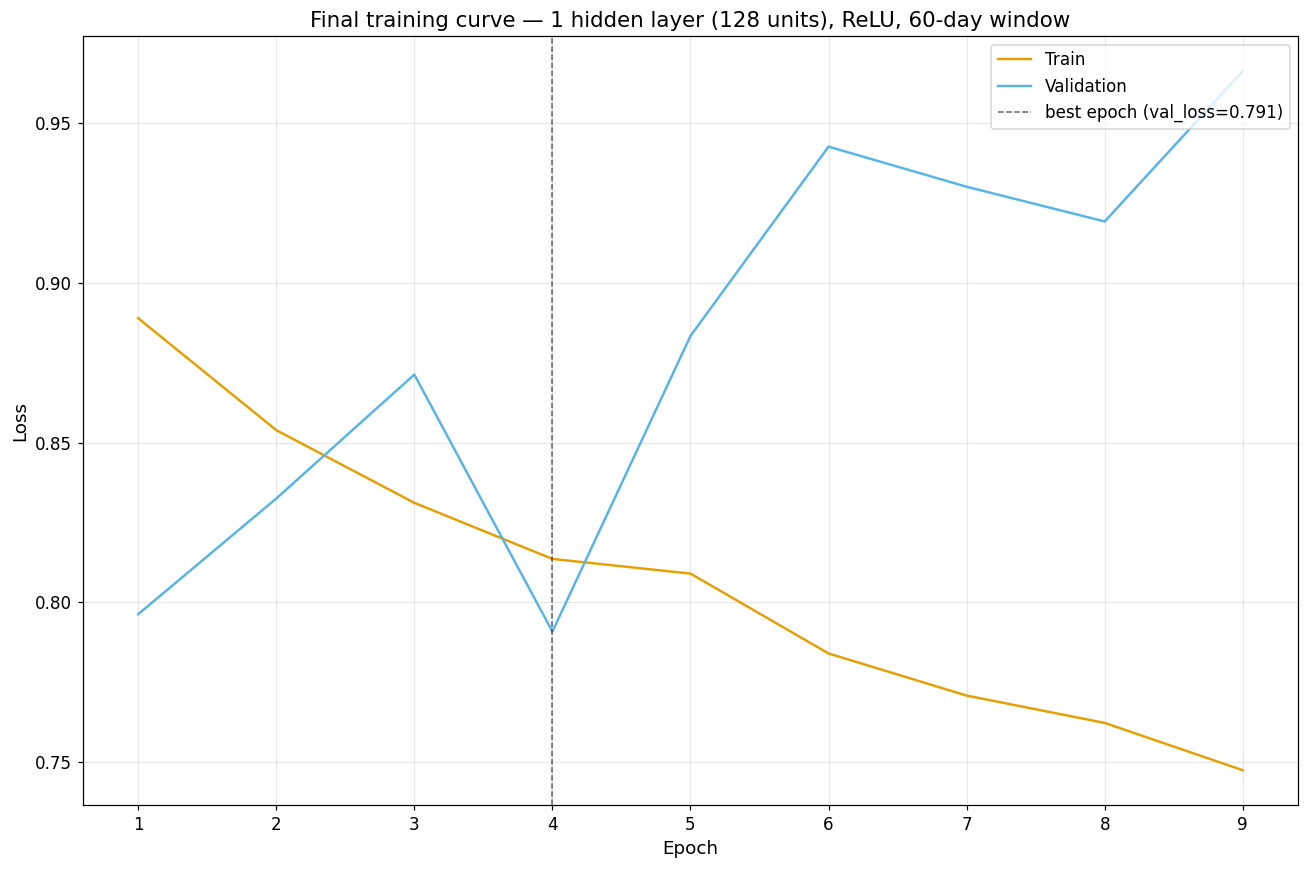

In [4]:
# T6 Cell 7 — Final (static) loss curve.  AC-3 "available as a
# plot without additional wiring" evidence — one function call on the
# fitted model's ``loss_history_`` attribute.

fig = plots.loss_curve(
    model.loss_history_,
    title="Final training curve — 1 hidden layer (128 units), ReLU, 60-day window",
)
best_epoch = model.metadata.hyperparameters["best_epoch"]
best_val = next(entry["val_loss"] for entry in model.loss_history_ if entry["epoch"] == best_epoch)
fig.axes[0].axvline(
    best_epoch,
    color=plots.OKABE_ITO[0],
    linestyle="--",
    linewidth=1.0,
    alpha=0.6,
    label=f"best epoch (val_loss={best_val:.3f})",
)
fig.axes[0].legend(loc="upper right")
fig.tight_layout()
plt.show()

## Comparing against the linear baseline + seasonal-naive

Intent §Scope closes with "*compares predictions against prior models*".
The honest comparison is through the Stage 6 rolling-origin harness:
fit each model on the same fold boundaries, collect MAE / MAPE / RMSE /
WAPE, and print the mean across folds.

The `NnMlpModel` here competes with the same `hidden_sizes=[128]`
defaults as the live-demo cell.  Expect the linear baseline to edge
the MLP on MAE and MAPE — the weather-only feature set is too narrow
for a 128-unit MLP to exploit a non-linear advantage (Stage 11's
temporal architecture is where the non-linearity starts paying
rent).  The seasonal-naive model is the "how hard could it be?" lower
bound: if the MLP cannot beat *that*, the stage has a bug.


In [5]:
# T6 Cell 9 — Three-way harness comparison over small rolling-origin
# folds.  Budget-friendly config: 3 folds of 168 h each, trained on
# ~720 h = 30 days.  A full-year rolling-origin pass belongs to the
# CLI (``python -m bristol_ml.train model=nn_mlp``), not to the
# notebook.

splitter_cfg = cfg.evaluation.rolling_origin.model_copy(
    update={
        "min_train_periods": 720,
        "test_len": 168,
        "step": 168,
        "fixed_window": True,
    }
)
metric_fns = [METRIC_REGISTRY[name] for name in ("mae", "mape", "rmse", "wape")]

# Instantiate fresh models so state from Cell 5 does not leak in.
cmp_nn_cfg = NnMlpConfig(
    target_column="nd_mw",
    hidden_sizes=[128],
    activation="relu",
    max_epochs=40,
    patience=5,
    batch_size=32,
    device="cpu",
)
naive_cfg = NaiveConfig(strategy="same_hour_last_week", target_column="nd_mw")
linear_cfg = LinearConfig(feature_columns=tuple(feature_cols), target_column="nd_mw")

results: dict[str, pd.DataFrame] = {}
for name, candidate in [
    ("naive", NaiveModel(naive_cfg)),
    ("linear", LinearModel(linear_cfg)),
    ("nn_mlp", NnMlpModel(cmp_nn_cfg)),
]:
    t0 = time.time()
    metrics_df = evaluate(
        candidate,
        df,
        splitter_cfg,
        metric_fns,
        target_column="nd_mw",
        feature_columns=tuple(feature_cols),
    )
    print(f"{name:>8s}  evaluate: {time.time() - t0:5.1f}s  ({len(metrics_df)} folds)")
    results[name] = metrics_df

metric_names = [fn.__name__ for fn in metric_fns]
summary_df = pd.concat(
    [results[m][metric_names].mean().rename(m) for m in results],
    axis=1,
).T
summary_df.index.name = "model"
print()
print("Mean metric across folds (lower is better):")
print(summary_df.to_string(float_format=lambda v: f"{v:.3f}"))

2026-04-24 13:31:41.262 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 0 train_len=720 test_len=168 metrics={'mae': 2513.904761904762, 'mape': 0.07539388249399018, 'rmse': 2887.903554566217, 'wape': 0.0738807013222696}


2026-04-24 13:31:41.264 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 1 train_len=720 test_len=168 metrics={'mae': 2709.0059523809523, 'mape': 0.09315233660559612, 'rmse': 3323.161082069443, 'wape': 0.08611409649952696}


2026-04-24 13:31:41.265 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 2 train_len=720 test_len=168 metrics={'mae': 3091.035714285714, 'mape': 0.11063033842206225, 'rmse': 3657.637601161243, 'wape': 0.1089647577924446}


2026-04-24 13:31:41.266 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 3 train_len=720 test_len=168 metrics={'mae': 4175.315476190476, 'mape': 0.17917619386497222, 'rmse': 5016.244246374544, 'wape': 0.17143050562801412}


2026-04-24 13:31:41.267 | INFO     | bristol_ml.evaluation.harness:evaluate:287 - Evaluator complete: total_folds=4 elapsed_seconds=0.006 summary={'mae': {'mean': 3122.315476190476, 'std': 642.412597797188}, 'mape': {'mean': 0.1145881878466552, 'std': 0.039315914029806893}, 'rmse': {'mean': 3721.2366210428618, 'std': 795.9267741773502}, 'wape': {'mean': 0.11009751531056383, 'std': 0.037582844604299205}}


...

2026-04-24 13:31:42.274 | INFO     | bristol_ml.models.nn.mlp:_select_device:121 - NnMlpModel: device preference='cpu' resolved to 'cpu'.


2026-04-24 13:31:42.354 | INFO     | bristol_ml.models.nn.mlp:fit:592 - NnMlpModel.fit: early stopping at epoch 6 (best_epoch=1 best_val_loss=0.721102).


2026-04-24 13:31:42.356 | INFO     | bristol_ml.evaluation.harness:evaluate:253 - Evaluator fold 3 train_len=720 test_len=168 metrics={'mae': 6010.290597098215, 'mape': 0.29083063192766323, 'rmse': 7107.49263433376, 'wape': 0.24677109116840346}


2026-04-24 13:31:42.357 | INFO     | bristol_ml.evaluation.harness:evaluate:287 - Evaluator complete: total_folds=4 elapsed_seconds=1.071 summary={'mae': {'mean': 5621.650602794829, 'std': 656.677246916821}, 'mape': {'mean': 0.20722989195949743, 'std': 0.048733621118238896}, 'rmse': {'mean': 6616.295017640055, 'std': 828.5180067582796}, 'wape': {'mean': 0.19293282165733713, 'std': 0.032601552000195204}}


  nn_mlp  evaluate:   1.1s  (4 folds)

Mean metric across folds (lower is better):
            mae  mape     rmse  wape
model                               
naive  3122.315 0.115 3721.237 0.110
linear 5690.834 0.212 6559.572 0.195
nn_mlp 5621.651 0.207 6616.295 0.193


## Closing — what the scaffold buys us, what's next

**What Stage 10 added over Stages 4 / 7.**  A PyTorch-backed `Model`
protocol conformer with a hand-rolled training loop (plan D10), a
four-stream reproducibility recipe (plan D7'), cold-start-per-fold
semantics (plan D8), and a `state_dict`-bytes-inside-joblib artefact
envelope (plan D5 revised) that plugs into the Stage 9 registry
without any registry change.  The analytical payoff (Cell 9's three-way
leaderboard) is typically *not* an MLP win on the weather-only feature
set — and the intent says so up front.  The training-loop conventions
and reproducibility discipline are the load-bearing contribution.

**Stage 11 hook.**  The `_run_training_loop` method carries an explicit
extraction-seam marker in the source — `# Stage 11 extraction seam:
move the body of this method and ``_make_mlp`` to
``src/bristol_ml/models/nn/_training.py`` when Stage 11's temporal
model arrives`.  Gradient clipping / LR scheduling are deliberately
**not** added at Stage 10 (scope-diff X6 cut); they belong behind the
shared helper, not in a growing `NnMlpModel`.

**Registry hook.**  `python -m bristol_ml.train model=nn_mlp` runs the
full rolling-origin pipeline end-to-end and registers the final-fold
model through the Stage 9 surface — the sidecar carries
`type = "nn_mlp"`, and `registry list --model-type nn_mlp` picks it up
alongside the other four families.  The leaderboard test covers this
wiring (see `tests/unit/registry/test_registry_nn_mlp_dispatch.py`).
